# Mixed variable

In [30]:
import numpy as np
import pandas as pd 

In [32]:
df = pd.read_csv("DATASET/mixed_var.csv")
df

,Cabin,Ticket,number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1
2,NaN,STON/O2. 3101282,6,1
3,C123,113803,3,1
4,NaN,373450,A,0
...,...,...,...,...
886,NaN,211536,3,0
887,B42,112053,3,1
888,NaN,W./C. 6607,1,0
889,C148,111369,2,1


In [33]:
df['number'].unique()

array(['5', '3', '6', 'A', '2', '1', '4'], dtype=object)

Text(0.5, 1.0, 'passenger travel with')

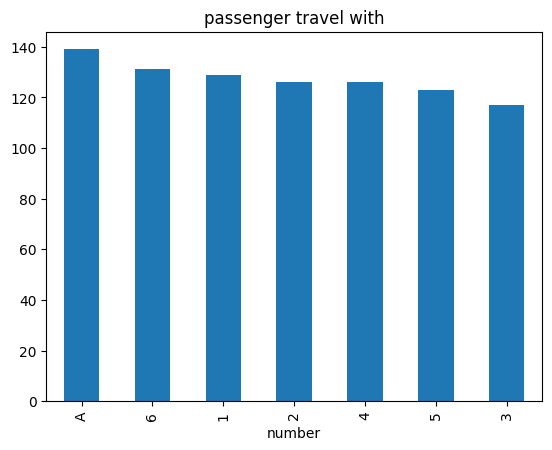

In [34]:
fig = df['number'].value_counts().plot.bar()
fig.set_title('passenger travel with')

### 1. extract the numerical part

In [37]:
df['number_numerical'] =pd.to_numeric(df['number'],errors='coerce',downcast='integer')

### 2.extract the categorical part 

In [38]:
df['number_categorical'] = np.where(df['number_numerical'].isnull(),df['number'],np.nan)

In [39]:
df.head(2)

,Cabin,Ticket,number,Survived,number_numerical,number_categorical
0,NaN,A/5 21171,5.0,0,5.0,NaN
1,C85,PC 17599,3.0,1,3.0,NaN


In [40]:
df['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [41]:
df['Ticket'].unique()

array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450',
       '330877', '17463', '349909', '347742', '237736', 'PP 9549',
       '113783', 'A/5. 2151', '347082', '350406', '248706', '382652',
       '244373', '345763', '2649', '239865', '248698', '330923', '113788',
       '347077', '2631', '19950', '330959', '349216', 'PC 17601',
       'PC 17569', '335677', 'C.A. 24579', 'PC 17604', '113789', '2677',
       'A./5. 2152', '345764', '2651', '7546', '11668', '349253',
       'SC/Paris 2123', '330958', 'S.C./A.4. 23567', '370371', '14311',
       '2662', '349237', '3101295', 'A/4. 39886', 'PC 17572', '2926',
       '113509', '19947', 'C.A. 31026', '2697', 'C.A. 34651', 'CA 2144',
       '2669', '113572', '36973', '347088', 'PC 17605', '2661',
       'C.A. 29395', 'S.P. 3464', '3101281', '315151', 'C.A. 33111',
       'S.O.C. 14879', '2680', '1601', '348123', '349208', '374746',
       '248738', '364516', '345767', '345779', '330932', '113059',
       'SO/C 14885', '31012

In [43]:
df['cabin_num'] = df['Cabin'].str.extract('(\d+)') # captures numerical part
df['cabin_cat'] = df['Cabin'].str[0] # captures the first letter

df.head()

,Cabin,Ticket,number,Survived,number_numerical,number_categorical,ticket_num,ticket_cat,cabin_num,cabin_cat
0,NaN,A/5 21171,5.0,0,5.0,NaN,21171.0,A/5,NaN,NaN
1,C85,PC 17599,3.0,1,3.0,NaN,17599.0,PC,85,C
2,NaN,STON/O2. 3101282,6.0,1,6.0,NaN,3101282.0,STON/O2.,NaN,NaN
3,C123,113803,3.0,1,3.0,NaN,113803.0,NaN,123,C
4,NaN,373450,NaN,0,NaN,NaN,373450.0,NaN,NaN,NaN


<Axes: xlabel='cabin_cat'>

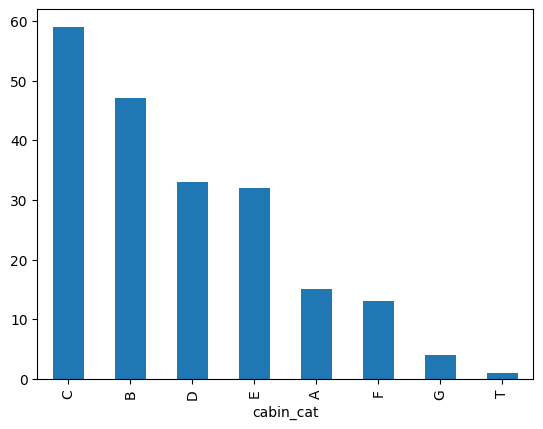

In [44]:
df['cabin_cat'].value_counts().plot(kind='bar')

In [42]:
# extract the last bit of ticket as number
df['ticket_num'] = df['Ticket'].apply(lambda s: s.split()[-1])
df['ticket_num'] = pd.to_numeric(df['ticket_num'],
                                   errors='coerce',
                                   downcast='integer')

# extract the first part of ticket as category
df['ticket_cat'] = df['Ticket'].apply(lambda s: s.split()[0])
df['ticket_cat'] = np.where(df['ticket_cat'].str.isdigit(), np.nan,
                              df['ticket_cat'])

df.head(20)

,Cabin,Ticket,number,Survived,number_numerical,number_categorical,ticket_num,ticket_cat
0,NaN,A/5 21171,5.0,0,5.0,NaN,21171.0,A/5
1,C85,PC 17599,3.0,1,3.0,NaN,17599.0,PC
2,NaN,STON/O2. 3101282,6.0,1,6.0,NaN,3101282.0,STON/O2.
3,C123,113803,3.0,1,3.0,NaN,113803.0,NaN
4,NaN,373450,NaN,0,NaN,NaN,373450.0,NaN
5,NaN,330877,2.0,0,2.0,NaN,330877.0,NaN
6,E46,17463,2.0,0,2.0,NaN,17463.0,NaN
7,NaN,349909,5.0,0,5.0,NaN,349909.0,NaN
8,NaN,347742,1.0,1,1.0,NaN,347742.0,NaN
9,NaN,237736,NaN,1,NaN,NaN,237736.0,NaN


In [45]:
df['ticket_cat'].unique()

array(['A/5', 'PC', 'STON/O2.', nan, 'PP', 'A/5.', 'C.A.', 'A./5.',
       'SC/Paris', 'S.C./A.4.', 'A/4.', 'CA', 'S.P.', 'S.O.C.', 'SO/C',
       'W./C.', 'SOTON/OQ', 'W.E.P.', 'STON/O', 'A4.', 'C', 'SOTON/O.Q.',
       'SC/PARIS', 'S.O.P.', 'A.5.', 'Fa', 'CA.', 'LINE', 'F.C.C.', 'W/C',
       'SW/PP', 'SCO/W', 'P/PP', 'SC', 'SC/AH', 'A/S', 'A/4', 'WE/P',
       'S.W./PP', 'S.O./P.P.', 'F.C.', 'SOTON/O2', 'S.C./PARIS',
       'C.A./SOTON'], dtype=object)

# Handling the Date time column

In [1]:
import numpy as np
import pandas as pd

In [2]:
# use two csv one is for date and other is for time 
date = pd.read_csv("DATASET/orders.csv")
time = pd.read_csv("DATASET/messages.csv")

In [3]:
date.head(2)

,date,product_id,city_id,orders
0,2019-12-10,5628,25,3
1,2018-08-15,3646,14,157


In [4]:
time.head(2)

,date,msg
0,2013-12-15 00:50:00,ищу на сегодня мужика 37
1,2014-04-29 23:40:00,ПАРЕНЬ БИ ИЩЕТ ДРУГА СЕЙЧАС!! СМС ММС 0955532826


In [5]:
print(date.info())
print()
print(time.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        1000 non-null   object
 1   product_id  1000 non-null   int64 
 2   city_id     1000 non-null   int64 
 3   orders      1000 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 31.4+ KB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    1000 non-null   object
 1   msg     1000 non-null   object
dtypes: object(2)
memory usage: 15.8+ KB
None


### 1. extract year

In [6]:
# first convert the date(object) to datetime datatype
date['date']=pd.to_datetime(date['date'])

In [7]:
date['date_year']=date['date'].dt.year
date

,date,product_id,city_id,orders,date_year
0,2019-12-10,5628,25,3,2019
1,2018-08-15,3646,14,157,2018
2,2018-10-23,1859,25,1,2018
3,2019-08-17,7292,25,1,2019
4,2019-01-06,4344,25,3,2019
...,...,...,...,...,...
995,2018-10-08,255,13,1,2018
996,2018-12-06,5521,7,1,2018
997,2019-05-07,487,26,14,2019
998,2019-03-03,1503,21,2,2019


### 2.extract month

In [8]:
# get the months out
date['date_month']=date['date'].dt.month

# get the month names
date['date_month_names'] = date['date'].dt.month_name()
date

,date,product_id,city_id,orders,date_year,date_month,date_month_names
0,2019-12-10,5628,25,3,2019,12,December
1,2018-08-15,3646,14,157,2018,8,August
2,2018-10-23,1859,25,1,2018,10,October
3,2019-08-17,7292,25,1,2019,8,August
4,2019-01-06,4344,25,3,2019,1,January
...,...,...,...,...,...,...,...
995,2018-10-08,255,13,1,2018,10,October
996,2018-12-06,5521,7,1,2018,12,December
997,2019-05-07,487,26,14,2019,5,May
998,2019-03-03,1503,21,2,2019,3,March


### 3.extract days

In [9]:
date['date_day'] =date['date'].dt.day

# day of the week 
date['day_of_week']= date['date'].dt.dayofweek

# day of week name 
date['date_day_of_week'] = date['date'].dt.day_name()
date

,date,product_id,city_id,orders,date_year,date_month,date_month_names,date_day,day_of_week,date_day_of_week
0,2019-12-10,5628,25,3,2019,12,December,10,1,Tuesday
1,2018-08-15,3646,14,157,2018,8,August,15,2,Wednesday
2,2018-10-23,1859,25,1,2018,10,October,23,1,Tuesday
3,2019-08-17,7292,25,1,2019,8,August,17,5,Saturday
4,2019-01-06,4344,25,3,2019,1,January,6,6,Sunday
...,...,...,...,...,...,...,...,...,...,...
995,2018-10-08,255,13,1,2018,10,October,8,0,Monday
996,2018-12-06,5521,7,1,2018,12,December,6,3,Thursday
997,2019-05-07,487,26,14,2019,5,May,7,1,Tuesday
998,2019-03-03,1503,21,2,2019,3,March,3,6,Sunday


In [10]:
# find out is weekend ?
date['is_weekend'] =np.where(date['day_of_week'].isin(['Sunday','Saturday']),1,0)
date

,date,product_id,city_id,orders,date_year,date_month,date_month_names,date_day,day_of_week,date_day_of_week,is_weekend
0,2019-12-10,5628,25,3,2019,12,December,10,1,Tuesday,0
1,2018-08-15,3646,14,157,2018,8,August,15,2,Wednesday,0
2,2018-10-23,1859,25,1,2018,10,October,23,1,Tuesday,0
3,2019-08-17,7292,25,1,2019,8,August,17,5,Saturday,0
4,2019-01-06,4344,25,3,2019,1,January,6,6,Sunday,0
...,...,...,...,...,...,...,...,...,...,...,...
995,2018-10-08,255,13,1,2018,10,October,8,0,Monday,0
996,2018-12-06,5521,7,1,2018,12,December,6,3,Thursday,0
997,2019-05-07,487,26,14,2019,5,May,7,1,Tuesday,0
998,2019-03-03,1503,21,2,2019,3,March,3,6,Sunday,0


### 4.extract week of year

In [11]:
date['date_week'] = date['date'].dt.isocalendar().week
date

,date,product_id,city_id,orders,date_year,date_month,date_month_names,date_day,day_of_week,date_day_of_week,is_weekend,date_week
0,2019-12-10,5628,25,3,2019,12,December,10,1,Tuesday,0,50
1,2018-08-15,3646,14,157,2018,8,August,15,2,Wednesday,0,33
2,2018-10-23,1859,25,1,2018,10,October,23,1,Tuesday,0,43
3,2019-08-17,7292,25,1,2019,8,August,17,5,Saturday,0,33
4,2019-01-06,4344,25,3,2019,1,January,6,6,Sunday,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
995,2018-10-08,255,13,1,2018,10,October,8,0,Monday,0,41
996,2018-12-06,5521,7,1,2018,12,December,6,3,Thursday,0,49
997,2019-05-07,487,26,14,2019,5,May,7,1,Tuesday,0,19
998,2019-03-03,1503,21,2,2019,3,March,3,6,Sunday,0,9


### 5.extract quarter

In [12]:
date['quarter'] =date['date'].dt.quarter
date

,date,product_id,city_id,orders,date_year,date_month,date_month_names,date_day,day_of_week,date_day_of_week,is_weekend,date_week,quarter
0,2019-12-10,5628,25,3,2019,12,December,10,1,Tuesday,0,50,4
1,2018-08-15,3646,14,157,2018,8,August,15,2,Wednesday,0,33,3
2,2018-10-23,1859,25,1,2018,10,October,23,1,Tuesday,0,43,4
3,2019-08-17,7292,25,1,2019,8,August,17,5,Saturday,0,33,3
4,2019-01-06,4344,25,3,2019,1,January,6,6,Sunday,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2018-10-08,255,13,1,2018,10,October,8,0,Monday,0,41,4
996,2018-12-06,5521,7,1,2018,12,December,6,3,Thursday,0,49,4
997,2019-05-07,487,26,14,2019,5,May,7,1,Tuesday,0,19,2
998,2019-03-03,1503,21,2,2019,3,March,3,6,Sunday,0,9,1


### 6.extract  semester

In [13]:
date['semester'] = np.where(date['quarter'].isin([1,2]),1,2)
date

,date,product_id,city_id,orders,date_year,date_month,date_month_names,date_day,day_of_week,date_day_of_week,is_weekend,date_week,quarter,semester
0,2019-12-10,5628,25,3,2019,12,December,10,1,Tuesday,0,50,4,2
1,2018-08-15,3646,14,157,2018,8,August,15,2,Wednesday,0,33,3,2
2,2018-10-23,1859,25,1,2018,10,October,23,1,Tuesday,0,43,4,2
3,2019-08-17,7292,25,1,2019,8,August,17,5,Saturday,0,33,3,2
4,2019-01-06,4344,25,3,2019,1,January,6,6,Sunday,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2018-10-08,255,13,1,2018,10,October,8,0,Monday,0,41,4,2
996,2018-12-06,5521,7,1,2018,12,December,6,3,Thursday,0,49,4,2
997,2019-05-07,487,26,14,2019,5,May,7,1,Tuesday,0,19,2,1
998,2019-03-03,1503,21,2,2019,3,March,3,6,Sunday,0,9,1,1


### 7.extract time elapsed between dates 

In [14]:
import datetime
today =datetime.datetime.today()
today

datetime.datetime(2026, 7, 15, 16, 45, 37, 372673)

In [15]:
today - date['date']

0     2409 days 16:45:37.372673
1     2891 days 16:45:37.372673
2     2822 days 16:45:37.372673
3     2524 days 16:45:37.372673
4     2747 days 16:45:37.372673
                 ...           
995   2837 days 16:45:37.372673
996   2778 days 16:45:37.372673
997   2626 days 16:45:37.372673
998   2691 days 16:45:37.372673
999   2465 days 16:45:37.372673
Name: date, Length: 1000, dtype: timedelta64[ns]

In [16]:
(today - date['date']).dt.days

0      2409
1      2891
2      2822
3      2524
4      2747
       ... 
995    2837
996    2778
997    2626
998    2691
999    2465
Name: date, Length: 1000, dtype: int64

In [20]:
#  months passed 
# Calculates exact calendar month difference ignoring the specific day
12 * (today.year - date['date'].dt.year) + (today.month - date['date'].dt.month)


0      79
1      95
2      93
3      83
4      90
       ..
995    93
996    91
997    86
998    88
999    81
Name: date, Length: 1000, dtype: int32

In [21]:
time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    1000 non-null   object
 1   msg     1000 non-null   object
dtypes: object(2)
memory usage: 15.8+ KB


In [23]:
# convert date in time into datetime datatype
time['date']= pd.to_datetime(time['date'])
time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1000 non-null   datetime64[ns]
 1   msg     1000 non-null   object        
dtypes: datetime64[ns](1), object(1)
memory usage: 15.8+ KB


In [24]:
time['hour'] = time['date'].dt.hour
time['min'] = time['date'].dt.minute
time['sec'] = time['date'].dt.second

time.head()

,date,msg,hour,min,sec
0,2013-12-15 00:50:00,ищу на сегодня мужика 37,0,50,0
1,2014-04-29 23:40:00,ПАРЕНЬ БИ ИЩЕТ ДРУГА СЕЙЧАС!! СМС ММС 0955532826,23,40,0
2,2012-12-30 00:21:00,Днепр.м 43 позн.с д/ж *.о 067.16.34.576,0,21,0
3,2014-11-28 00:31:00,КИЕВ ИЩУ Д/Ж ДО 45 МНЕ СЕЙЧАС СКУЧНО 093 629 9...,0,31,0
4,2013-10-26 23:11:00,Зая я тебя никогда не обижу люблю тебя!) Даше,23,11,0


### 8.extract the time part

In [25]:

time['time'] = time['date'].dt.time

time.head()

,date,msg,hour,min,sec,time
0,2013-12-15 00:50:00,ищу на сегодня мужика 37,0,50,0,00:50:00
1,2014-04-29 23:40:00,ПАРЕНЬ БИ ИЩЕТ ДРУГА СЕЙЧАС!! СМС ММС 0955532826,23,40,0,23:40:00
2,2012-12-30 00:21:00,Днепр.м 43 позн.с д/ж *.о 067.16.34.576,0,21,0,00:21:00
3,2014-11-28 00:31:00,КИЕВ ИЩУ Д/Ж ДО 45 МНЕ СЕЙЧАС СКУЧНО 093 629 9...,0,31,0,00:31:00
4,2013-10-26 23:11:00,Зая я тебя никогда не обижу люблю тебя!) Даше,23,11,0,23:11:00


### 9.time difference

In [26]:
today - time['date']

0     4595 days 15:55:37.372673
1     4459 days 17:05:37.372673
2     4945 days 16:24:37.372673
3     4247 days 16:14:37.372673
4     4644 days 17:34:37.372673
                 ...           
995   5234 days 15:55:37.372673
996   4555 days 17:31:37.372673
997   5020 days 17:08:37.372673
998   5136 days 17:11:37.372673
999   4408 days 17:20:37.372673
Name: date, Length: 1000, dtype: timedelta64[ns]

In [27]:
# in seconds

(today - time['date'])/np.timedelta64(1,'s')

0      3.970653e+08
1      3.853191e+08
2      4.273071e+08
3      3.669993e+08
4      4.013049e+08
           ...     
995    4.522749e+08
996    3.936151e+08
997    4.337897e+08
998    4.438123e+08
999    3.809136e+08
Name: date, Length: 1000, dtype: float64

In [28]:
# in minutes

(today - time['date'])/np.timedelta64(1,'m')

0      6.617756e+06
1      6.421986e+06
2      7.121785e+06
3      6.116655e+06
4      6.688415e+06
           ...     
995    7.537916e+06
996    6.560252e+06
997    7.229829e+06
998    7.396872e+06
999    6.348561e+06
Name: date, Length: 1000, dtype: float64

In [29]:
# in hours

(today - time['date'])/np.timedelta64(1,'h')

0      110295.927048
1      107033.093715
2      118696.410381
3      101944.243715
4      111473.577048
           ...      
995    125631.927048
996    109337.527048
997    120497.143715
998    123281.193715
999    105809.343715
Name: date, Length: 1000, dtype: float64